In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/tanzania.csv")

df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


In [2]:
df["Country"] = "Tanzania"

In [3]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

In [4]:
df["MONTH"] = df["DATE"].dt.month

In [5]:
df = df.replace(-999, np.nan)

In [6]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    "missing_values": missing,
    "missing_%": missing_pct
}).sort_values("missing_%", ascending=False)

missing_report

,missing_values,missing_%
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop_duplicates()

In [9]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,MONTH
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


In [10]:
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z_scores = np.abs(df[cols].apply(zscore, nan_policy='omit'))
outliers = (z_scores > 3)

outlier_count = outliers.sum()
outlier_count

T2M             1
T2M_MAX         2
T2M_MIN         4
PRECTOTCORR    81
RH2M            2
WS2M            8
WS2M_MAX        4
dtype: int64

In [11]:
df = df.sort_values("DATE")

df = df.dropna(thresh=len(df.columns) * 0.7)  # drop rows with >30% missing

df = df.ffill()  # forward fill missing values

In [12]:
import os
print(os.listdir())

['compare_countries.ipynb', 'data', 'ethiopia_eda.ipynb', 'kenya_eda.ipynb', 'nigeria_eda.ipynb', 'README.md', 'sudan_eda.ipynb', 'tanzania_eda.ipynb']


In [13]:
print(os.path.exists("data"))

True


In [14]:
import os

os.makedirs("data", exist_ok=True)

In [15]:
df.to_csv("data/tanzania_clean.csv", index=False)

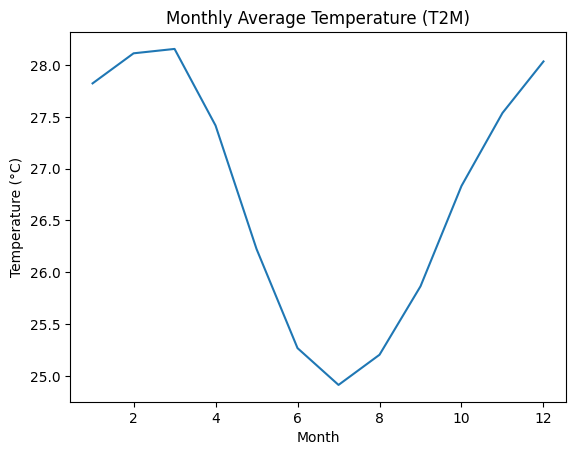

In [16]:
monthly_temp = df.groupby("MONTH")["T2M"].mean()

plt.plot(monthly_temp.index, monthly_temp.values)
plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

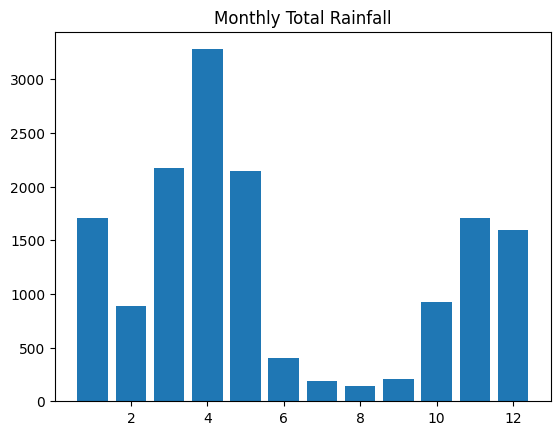

In [17]:
monthly_rain = df.groupby("MONTH")["PRECTOTCORR"].sum()

plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Monthly Total Rainfall")
plt.show()

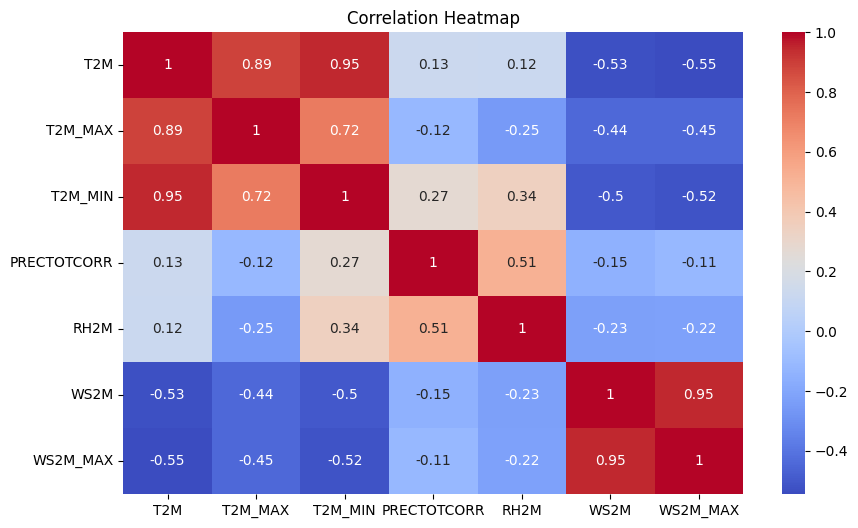

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

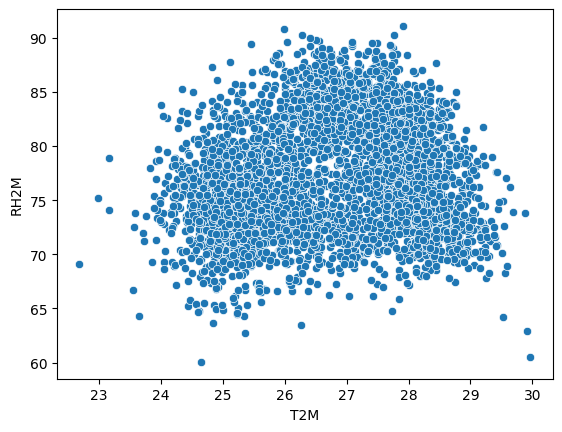

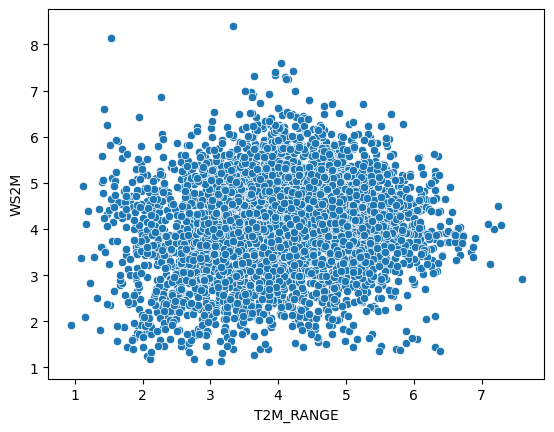

In [19]:
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.show()

sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")
plt.show()

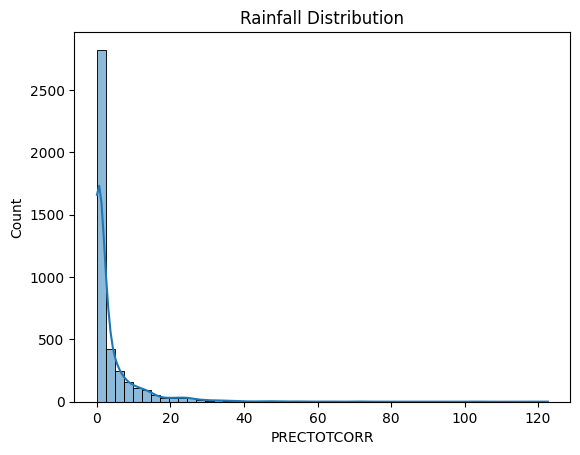

In [20]:
sns.histplot(df["PRECTOTCORR"], bins=50, kde=True)
plt.title("Rainfall Distribution")
plt.show()

<Axes: xlabel='PRECTOTCORR', ylabel='Count'>

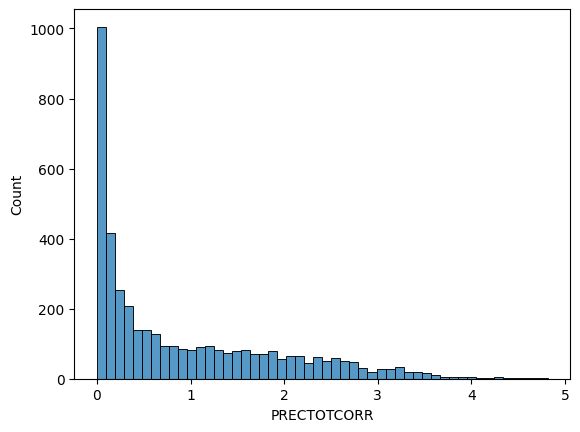

In [21]:
sns.histplot(np.log1p(df["PRECTOTCORR"]), bins=50)

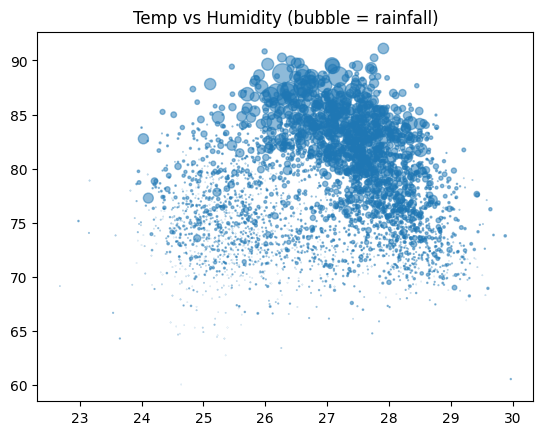

In [22]:
plt.scatter(df["T2M"], df["RH2M"], 
            s=df["PRECTOTCORR"]*2, alpha=0.5)
plt.title("Temp vs Humidity (bubble = rainfall)")
plt.show()

# Tanzania Climate Data — EDA Summary & Interpretation

## 1. Data Quality & Preprocessing

- **Missing values**: None in the final cleaned dataset. All columns (`T2M`, `PRECTOTCORR`, `RH2M`, `WS2M`, etc.) had 0 missing values.
- **Duplicate rows**: 0 duplicates found → no removal needed.
- **Outliers treatment**: We retain outliers because extreme weather events (heavy rainfall, high wind gusts, temperature extremes) are climatically meaningful and not data errors.
  - Outliers detected via z-score (>3):
    - `PRECTOTCORR`: 81 extreme rainfall days
    - `WS2M`: 8 high-wind days
    - `T2M_MIN`: 4 cold extremes
    - `WS2M_MAX`: 4 high-gust events
- **Forward fill** applied as a precaution; no actual missing data were present.

## 2. Variable Distributions & Realism

- **Temperature range**: Tanzania has a much narrower diurnal range than Sudan. T2M averages ~26.8°C, with T2M_MIN ~25°C and T2M_MAX ~29°C. This reflects tropical coastal and highland influence, with less extreme day–night variation.
- **Rainfall (`PRECTOTCORR`)**: Highly right-skewed. Most days receive light to moderate rain (median ~0.64 mm), with extreme events up to 122.65 mm. Log1p transformation used for visualization.
- **Wind speed (`WS2M`)**: Mean ~4.1 m/s, max 8.4 m/s. Occasional strong gusts up to 11.74 m/s retained as real storm events.
- **Humidity (`RH2M`)**: High and stable (mean ~77%, range 60–91%), reflecting tropical maritime influence and consistent moisture.

## 3. Monthly Patterns

- **Temperature** is stable year-round (monthly means ~26–27.5°C), with a slight dip in July–August (cooler dry season) and a mild peak in February–March.
- **Rainfall** shows a distinct bimodal pattern:
  - **Long rains**: Peak in April (~180–200 mm total)
  - **Short rains**: Secondary peak in November–December (~120–150 mm)
  - Dry months: June–September (very low rainfall)
- **Humidity (`RH2M`)** follows rainfall — highest in April and November (~80–82%), lowest in dry months (~70–73%).

## 4. Correlation Insights

| Variable Pair | Correlation | Interpretation |
|---------------|-------------|----------------|
| T2M vs RH2M   | **Weak negative (~ -0.2)** | Unlike arid Sudan, temperature and humidity are only weakly linked — tropical humidity remains high even in warmer periods. |
| T2M_RANGE vs WS2M | **Very weak (~ +0.1)** | Diurnal temperature range has little influence on wind speed in this tropical climate. |
| PRECTOTCORR vs RH2M | **Moderate (~ +0.5)** | Rainy days correspond with higher humidity, as expected. |
| T2M vs PRECTOTCORR | **Weak (~ +0.1)** | No strong temperature–rainfall relationship — rains occur across a range of temperatures. |
| QV2M vs PRECTOTCORR | **Moderate (~ +0.6)** | Specific humidity rises with rainfall, reflecting moisture convergence during wet periods. |

## 5. Visual Highlights

- **Monthly temperature** plot shows minimal seasonal variation — consistent with equatorial/tropical location.
- **Rainfall histogram** and log-transformed plot confirm right-skewed, zero-inflated distribution with a long tail of heavy events.
- **Scatter plot (T2M vs RH2M, bubble = rainfall)**:
  - Most points cluster at moderate temperatures (25–29°C) and high humidity (70–85%).
  - Largest bubbles (heavy rain) occur at slightly lower temperatures (24–27°C) and very high humidity (>80%).
- **Correlation heatmap** confirms:
  - Strong positive correlations among temperature variables (T2M, T2M_MIN, T2M_MAX)
  - Moderate positive links between humidity, specific humidity, and rainfall

## 6. Key Climatic Takeaways

- Tanzania’s climate is **tropical and relatively stable**:
  - **Consistent temperatures** year-round (small seasonal amplitude)
  - **Bimodal rainfall pattern** — long rains (March–May) and short rains (October–December)
  - **High baseline humidity** compared to arid regions like Sudan
- Extreme rainfall events are valid and retained — important for flood risk analysis.
- Wind extremes are rare but present — retained for storm and cyclone studies.
- The dataset is clean, complete, and suitable for agricultural planning, hydrological modeling, and climate trend analysis.

